### STATIONARY TEST
| Test Name | Null Hypothesis | Interpretation of p-value |
|-----------|----------------|---------------------------|
| Augmented Dickey-Fuller (ADF) Test | Non-stationary (Has unit root) | p < 0.05: Reject null, series is stationary<br>p > 0.05: Fail to reject null, series is non-stationary |
| Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test | Stationary | p > 0.1: Fail to reject Null. No unit root and is stationary<br>p <=0.1: Reject Null. Has unit root, indicating it is non-stationary |

Note that it's generally good practice to use multiple tests as they have different strengths and assumptions. The ADF and KPSS tests are often used together since they have opposite null hypotheses, providing more robust conclusions about stationarity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

In [2]:
pd.options.mode.chained_assignment = None 
pd.options.display.float_format = '{:.4f}'.format
def scientific_formatter(x):
    try:
        return "{:.3f}".format(x)
    except Exception:
        return x

## Helper Function
Run and skip to the next cell

In [3]:
def stationarity_test(ts, lags = None):
    """
    The function runs stationarity, autocorrelation, and heteroskedasticity
    
    Parameters
    ----------
    ts: pd.DataFrame
        A time series
    lags: int
        How many lags to test the 
    """
    final_dict = {}
    labels = ['Test Statistic','P-Value','Lags','Observation','1%','5%','10%',"Null Hypo.","Stationary","Details"]
    
    #ADF
    if lags is not None:
        temp = adfuller(ts, maxlag=lags)
    else:
        temp = adfuller(ts)
    temp = list(temp[:4]) + [temp[4]["1%"],temp[4]["5%"],temp[4]["10%"], "Non-stationary (Has unit root)"]
    if temp[1] <= 0.05:
        temp.append("Yes")
        msg = "Reject Null. No unit root and is stationary"         
        print("ADF: " + msg)
    else:
        temp.append("No")
        msg = "Accept Null. Unit root, indicating it is non-stationary"
        print("ADF: " + msg)
    temp.append(msg)
    final_dict["ADF"] = dict(zip(labels,temp))
    
    #KPSS
    if lags is not None:
        temp = kpss(ts, nlags = lags)
    else:
        temp = kpss(ts)
    temp = list(temp[:3]) + [""] + [temp[3]["1%"],temp[3]["5%"],temp[3]["10%"],"Stationary (No unit root)"]
    if temp[1] > 0.1:
        temp.append("Yes")
        msg = "Fail to reject Null. No unit root and is stationary"
        print("KPSS: " + msg)        
    else:
        temp.append("No")
        msg = "Reject Null. Has unit root, indicating it is non-stationary"
        print("KPSS: " + msg)
    temp.append(msg)
    final_dict["KPSS"] = dict(zip(labels,temp))
    
    temp = pd.DataFrame(final_dict)
    temp = temp.map(scientific_formatter) #Format 3 decimal places
    return temp.T

## Time Series in levels

In [4]:
#**A FINANCIAL TIME SERIES***
usd_cad = pd.read_csv("../../../data/USD_CAD.csv")
usd_cad.set_index("time",inplace=True)

<Axes: xlabel='time'>

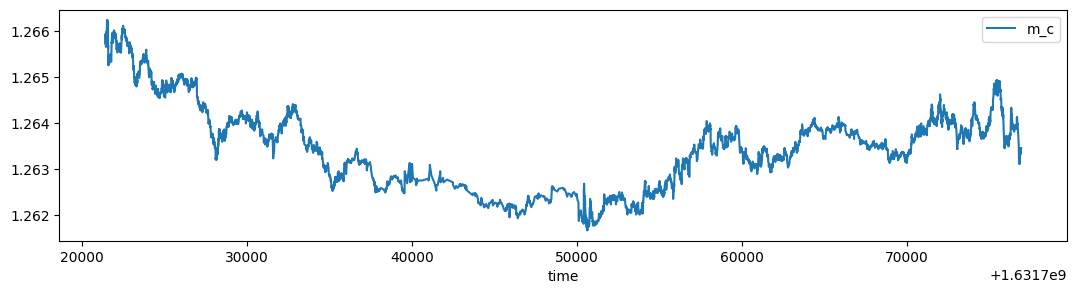

In [5]:
usd_cad[["m_c"]].plot(figsize=(13,3))

In [6]:
stationarity_test(usd_cad[["m_c"]])

ADF: Accept Null. Unit root, indicating it is non-stationary
KPSS: Reject Null. Has unit root, indicating it is non-stationary


/tmp/ipykernel_25463/1767240246.py:36: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  temp = kpss(ts)


,Test Statistic,P-Value,Lags,Observation,1%,5%,10%,Null Hypo.,Stationary,Details
ADF,-2.688,0.076,0.000,4999.000,-3.432,-2.862,-2.567,Non-stationary (Has unit root),No,"Accept Null. Unit root, indicating it is non-s..."
KPSS,3.227,0.010,42.000,,0.739,0.463,0.347,Stationary (No unit root),No,"Reject Null. Has unit root, indicating it is n..."


## Time Series in log difference or log change.

<Axes: xlabel='time'>

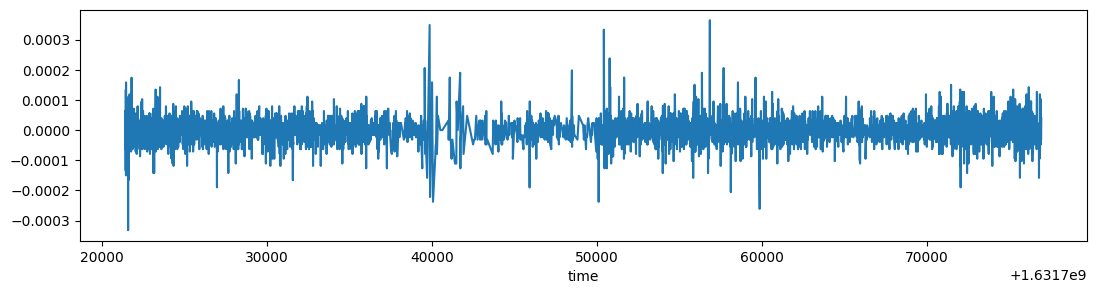

In [11]:
ts_diff = np.log(usd_cad.m_c).diff().dropna()
ts_diff.plot(figsize=(13,3))

In [12]:
stationarity_test(ts_diff, lags=6)

ADF: Reject Null. No unit root and is stationary
KPSS: Reject Null. Has unit root, indicating it is non-stationary


/tmp/ipykernel_25463/1767240246.py:34: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  temp = kpss(ts, nlags = lags)


,Test Statistic,P-Value,Lags,Observation,1%,5%,10%,Null Hypo.,Stationary,Details
ADF,-50.978,0.000,1.000,4997.000,-3.432,-2.862,-2.567,Non-stationary (Has unit root),Yes,Reject Null. No unit root and is stationary
KPSS,0.139,0.100,6.000,,0.739,0.463,0.347,Stationary (No unit root),No,"Reject Null. Has unit root, indicating it is n..."
